# Social Engine Round 2 — NLP Baseline
Run this notebook top-to-bottom. It trains separate sentiment and topic classifiers and saves metrics, confusion matrices, error CSVs, and `.pkl` models.

In [78]:
# Installing required dependencies for data processing,
# machine learning modeling, and plotting metrics.
%pip install -q pandas scikit-learn matplotlib joblib

In [79]:
# Importing necessary libraries and modules for data handling,
# machine learning pipelines, evaluation metrics, and model persistence.
from pathlib import Path
import pandas as pd, json, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

# Setting up paths for the training data and the output directory.
DATA = Path("Labeled_Social_NLP_Training_Data.csv")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

# Loading the dataset and previewing the first few rows.
df = pd.read_csv(DATA)
df.head()

,text_id,post_text,sentiment_label,topic_category
0,TXT_00001,some1 come wait in line with me Thursday at 3@target bc briana is being a bitch,Negative,Community_Discussion
1,TXT_00002,Mancity strikers Aguero and Dzeko you better thrash Bolton tomorrow night!,Positive,Community_Discussion
2,TXT_00003,Would you like to join us at our annual gala at the Sandman Signature Resort on Oct 25? Contact our centre at 6042773100 for tickets!,Positive,Community_Discussion
3,TXT_00004,"""Sicily may form grand coalition, Italian UDC Party leader: (AGI) Rome - On Monday Rocco Buttiglione, the leader ...",Neutral,Community_Discussion
4,TXT_00005,@user @user If the comment was in reference to the 'Charlie Hebdo' violent attack in january: it is no less repugnant. In my opinion,Negative,Community_Discussion


In [80]:
# Displaying the shape of the dataset, checking for missing values,
# counting sentiment and topic distributions, and checking for duplicates.
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nSentiment counts:\n", df.sentiment_label.value_counts())
print("\nTopic counts:\n", df.topic_category.value_counts())
print("Duplicate IDs:", df.text_id.duplicated().sum())
print("Duplicate post texts:", df.post_text.duplicated().sum())

Shape: (9000, 4)

Missing values:
 text_id            0
post_text          0
sentiment_label    0
topic_category     0
dtype: int64

Sentiment counts:
 sentiment_label
Negative    3000
Positive    3000
Neutral     3000
Name: count, dtype: int64

Topic counts:
 topic_category
Community_Discussion    7752
Technical_Issues         815
Feature_Feedback         297
Account_Security         136
Name: count, dtype: int64
Duplicate IDs: 0
Duplicate post texts: 1100


## Split and train
Identical text is grouped into one side of the split when labels are consistent, reducing train/test leakage.

In [84]:
# Cleaning the dataset by removing missing entries and whitespace,
# then splitting the data into training and test sets while preventing data leakage.
df = df.dropna(subset=["post_text","sentiment_label","topic_category"]).copy()
df["post_text"] = df["post_text"].astype(str).str.strip()
df = df[df.post_text.ne("")].copy()
conflicts = df.groupby("post_text")[["sentiment_label","topic_category"]].nunique().max(axis=1).gt(1).any()
if not conflicts:
    unique = df[["post_text","sentiment_label","topic_category"]].drop_duplicates("post_text")
    tr, te = train_test_split(unique["post_text"], test_size=0.2, random_state=42,
                              stratify=unique["sentiment_label"])
    train_df, test_df = df[df.post_text.isin(set(tr))], df[df.post_text.isin(set(te))]
else:
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42,
                                         stratify=df.sentiment_label)
print("Conflicting labels for identical text:", conflicts)
print("Train rows:", len(train_df), "Test rows:", len(test_df))

Conflicting labels for identical text: False
Train rows: 7211 Test rows: 1789


## Error analysis
Open the generated `*_errors.csv` files, inspect representative mistakes, and record recurring causes in the report. Do not infer performance before running all cells.

In [85]:

import pandas as pd
from pathlib import Path
from IPython.display import display

OUT = Path("outputs")

sentiment_errors = pd.read_csv(
    OUT / "sentiment_label_errors.csv"
)

topic_errors = pd.read_csv(
    OUT / "topic_category_errors.csv"
)

print("Sentiment errors:", len(sentiment_errors))
print("Topic errors:", len(topic_errors))

display(sentiment_errors.head(10))

Sentiment errors: 730
Topic errors: 168


,text_id,post_text,sentiment_label,predicted
0,TXT_00016,Nokia n97 microcosm - bear down upon the whole direct over and above utterly comprehensive march: OUYtuJ,Neutral,Positive
1,TXT_00033,The game 1st album 1 song he say he rap like Eazy-E then Nas then 50 cent then dr Dre then Jay-Z then Eazy-E again then like his dead bro,Positive,Negative
2,TXT_00058,"dj khaled // hold you down ft. chris brown, august alsina, future, jeremih",Neutral,Positive
3,TXT_00111,Jeff\u002c Joseph Arthur and the amazing Richard Stuverud.... Fox Theater in Bolder\u002c November 18th. DO NOT MISS THIS!...,Positive,Neutral
4,TXT_00114,"""He then said """"Kendrick Lamar will be the a huge rapper"""". He may be a genius""",Positive,Negative
5,TXT_00139,Chelsea need to beat Ajax to keep up there battle with Ajax for 2nd place #NextGenSeries,Neutral,Positive
6,TXT_00143,Fucking part time fans. Where were you at Boro away on Saturday?,Negative,Neutral
7,TXT_00153,guys remember that tomorrow is the last day you can donate to Pennies for Polio!!,Neutral,Positive
8,TXT_00171,dont get paid till saturday but im going traffod centre tonight\u002c cba,Negative,Neutral
9,TXT_00179,"Added psychotic to my library when year 12 starts tomorrow #smartmove #gonnafail""",Negative,Positive


In [59]:

display(topic_errors.head(10))

,text_id,post_text,topic_category,predicted
0,TXT_00024,Iqaluit just wouldn\u2019t be Iqaluit without the drunks screaming at each other on a Saturday morning ... depressing buggers.,Technical_Issues,Community_Discussion
1,TXT_00080,"""Kinda, yes! I went to see Equalizer tonite! I like it. It was very interesting modern day John Wayne movie...U may like it. @user",Feature_Feedback,Community_Discussion
2,TXT_00104,Why is my mind doing this to me? 1st I think about Max and how he always knows when I\u2019m sad and now I think about what happens when he dies,Technical_Issues,Community_Discussion
3,TXT_00114,"""He then said """"Kendrick Lamar will be the a huge rapper"""". He may be a genius""",Technical_Issues,Community_Discussion
4,TXT_00289,"""Market meltdown on the SPX is likely a 3rd wave, nice try to stop the crash, but they cant stop it now (well dont look like it)""",Technical_Issues,Community_Discussion
5,TXT_00313,If I'm Dustin Johnson I wouldn't care about my Sunday meltdowns going home to Paulina. #sheesh,Technical_Issues,Community_Discussion
6,TXT_00353,So disappointed with the movie Ghost Rider: Spirit of Vengeance. So not better than the 1st Ghost Rider movie,Technical_Issues,Community_Discussion
7,TXT_00468,Walking through Glasgow in the pissing rain then George Harrison's dulcet tones appear on my earphones with 'Here Comes The Sun'. Nice.,Technical_Issues,Community_Discussion
8,TXT_00470,@user @user HELP!! Bobby Jindal has just doomed Louisana.,Feature_Feedback,Community_Discussion
9,TXT_00495,Mighty Quinn: November 14: And the the winner is ... Curtis The Boxer:,Feature_Feedback,Community_Discussion


In [86]:

print(
    pd.crosstab(
        sentiment_errors["sentiment_label"],
        sentiment_errors["predicted"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )
)

Predicted  Negative  Neutral  Positive
Actual                                
Negative          0      130        77
Neutral         166        0       117
Positive         77      163         0


In [87]:

print(
    pd.crosstab(
        topic_errors["topic_category"],
        topic_errors["predicted"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )
)

Predicted             Account_Security  Community_Discussion  \
Actual                                                         
Account_Security                     0                    17   
Community_Discussion                 5                     0   
Feature_Feedback                     0                    66   
Technical_Issues                     0                    60   

Predicted             Feature_Feedback  Technical_Issues  
Actual                                                    
Account_Security                     0                 1  
Community_Discussion                 9                 9  
Feature_Feedback                     0                 0  
Technical_Issues                     1                 0  


In [88]:

pd.set_option("display.max_colwidth", 250)

display(
    sentiment_errors[
        ["text_id", "post_text",
         "sentiment_label", "predicted"]
    ].head(20)
)

,text_id,post_text,sentiment_label,predicted
0,TXT_00016,Nokia n97 microcosm - bear down upon the whole direct over and above utterly comprehensive march: OUYtuJ,Neutral,Positive
1,TXT_00033,The game 1st album 1 song he say he rap like Eazy-E then Nas then 50 cent then dr Dre then Jay-Z then Eazy-E again then like his dead bro,Positive,Negative
2,TXT_00058,"dj khaled // hold you down ft. chris brown, august alsina, future, jeremih",Neutral,Positive
3,TXT_00111,Jeff\u002c Joseph Arthur and the amazing Richard Stuverud.... Fox Theater in Bolder\u002c November 18th. DO NOT MISS THIS!...,Positive,Neutral
4,TXT_00114,"""He then said """"Kendrick Lamar will be the a huge rapper"""". He may be a genius""",Positive,Negative
5,TXT_00139,Chelsea need to beat Ajax to keep up there battle with Ajax for 2nd place #NextGenSeries,Neutral,Positive
6,TXT_00143,Fucking part time fans. Where were you at Boro away on Saturday?,Negative,Neutral
7,TXT_00153,guys remember that tomorrow is the last day you can donate to Pennies for Polio!!,Neutral,Positive
8,TXT_00171,dont get paid till saturday but im going traffod centre tonight\u002c cba,Negative,Neutral
9,TXT_00179,"Added psychotic to my library when year 12 starts tomorrow #smartmove #gonnafail""",Negative,Positive


In [89]:

# Add columns for your manual analysis
sentiment_review = sentiment_errors.copy()

sentiment_review["error_type"] = ""
sentiment_review["analysis_notes"] = ""
sentiment_review["possible_improvement"] = ""

topic_review = topic_errors.copy()

topic_review["error_type"] = ""
topic_review["analysis_notes"] = ""
topic_review["possible_improvement"] = ""

sentiment_review.to_csv(
    OUT / "sentiment_error_analysis_worksheet.csv",
    index=False
)

topic_review.to_csv(
    OUT / "topic_error_analysis_worksheet.csv",
    index=False
)

print("Worksheets created successfully!")

Worksheets created successfully!


In [64]:

import pandas as pd
from pathlib import Path

OUT = Path("outputs")

def auto_analyze(filename, task):
    df = pd.read_csv(OUT / filename)

    def classify(row):
        text = str(row["post_text"]).lower()

        if any(w in text for w in [
            " lol", "yeah right", "great, another",
            "just what i needed", "oh great"
        ]):
            return (
                "Possible sarcasm",
                "The wording may be sarcastic; verify manually.",
                "Consider contextual or sarcasm-aware features."
            )

        if task == "sentiment":
            return (
                "Sentiment ambiguity",
                f"Actual: {row['sentiment_label']}; "
                f"predicted: {row['predicted']}. "
                "Inspect the wording and context to identify why.",
                "Review ambiguous examples and test contextual models."
            )

        return (
            "Topic overlap / needs review",
            f"Actual: {row['topic_category']}; "
            f"predicted: {row['predicted']}. "
            "Check whether the post contains overlapping topics "
            "or lacks distinctive keywords.",
            "Review topic definitions and add representative examples."
        )

    df[["error_type", "analysis_notes",
        "possible_improvement"]] = df.apply(
        lambda row: pd.Series(classify(row)), axis=1
    )

    output = OUT / filename.replace(
        "_errors.csv", "_error_analysis_worksheet.csv"
    )
    df.to_csv(output, index=False)

    print(f"Saved: {output}")
    print("Rows filled:", len(df))

    return df

sentiment_review = auto_analyze(
    "sentiment_label_errors.csv", "sentiment"
)

topic_review = auto_analyze(
    "topic_category_errors.csv", "topic"
)

Saved: outputs/sentiment_label_error_analysis_worksheet.csv
Rows filled: 730
Saved: outputs/topic_category_error_analysis_worksheet.csv
Rows filled: 168


In [65]:

from google.colab import files

files.download(
    "outputs/sentiment_label_error_analysis_worksheet.csv"
)

files.download(
    "outputs/topic_category_error_analysis_worksheet.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
from pathlib import Path


custom_folder = Path("my_folder")
custom_folder.mkdir(exist_ok=True)


sentiment_review.to_csv(custom_folder / "sentiment_error_analysis_worksheet.csv", index=False)
topic_review.to_csv(custom_folder / "topic_error_analysis_worksheet.csv", index=False)

print("Files saved to:", custom_folder.resolve())

Files saved to: /content/my_folder


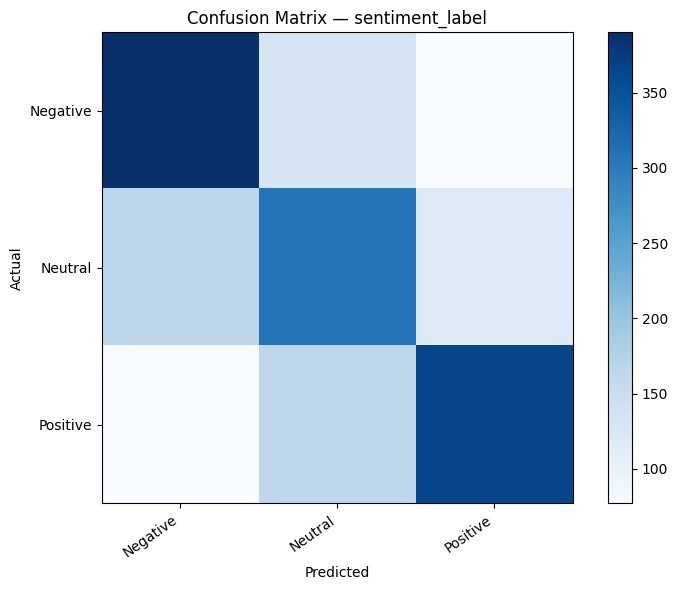

In [67]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import joblib
import pandas as pd

# Agar aapko sentiment model ke liye evaluate karna hai:
target = "sentiment_label"

# Agar aapne train_eval function use kiya hai, toh model ko joblib se load kar sakte hain ya direct pipeline use kar sakte hain:
model = joblib.load(OUT / f"{target}_model.pkl")

# Predictions aur True labels
y_true = test_df[target]
y_pred = model.predict(test_df.post_text)
labels = sorted(df[target].unique())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plotting
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix — {target}")
plt.colorbar()

tick_marks = range(len(labels))
plt.xticks(tick_marks, labels, rotation=35, ha="right")
plt.yticks(tick_marks, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [68]:
from google.colab import files

files.download("outputs/sentiment_label_confusion_matrix.png")
files.download("outputs/topic_category_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
# I am checking the performance of both models
# so I can identify which task needs more improvement.

from sklearn.metrics import classification_report
import joblib

# Sentiment model load karke predictions nikalna
sentiment_model = joblib.load("outputs/sentiment_label_model.pkl")
y_pred_sentiment = sentiment_model.predict(test_df.post_text)

print("SENTIMENT MODEL RESULTS")
print(classification_report(test_df["sentiment_label"], y_pred_sentiment, zero_division=0))

# Topic model load karke predictions nikalna
topic_model = joblib.load("outputs/topic_category_model.pkl")
y_pred_topic = topic_model.predict(test_df.post_text)

print("\nTOPIC MODEL RESULTS")
print(classification_report(test_df["topic_category"], y_pred_topic, zero_division=0))

SENTIMENT MODEL RESULTS
              precision    recall  f1-score   support

    Negative       0.62      0.65      0.63       597
     Neutral       0.51      0.52      0.52       590
    Positive       0.65      0.60      0.63       602

    accuracy                           0.59      1789
   macro avg       0.59      0.59      0.59      1789
weighted avg       0.59      0.59      0.59      1789


TOPIC MODEL RESULTS
                      precision    recall  f1-score   support

    Account_Security       0.62      0.31      0.41        26
Community_Discussion       0.91      0.99      0.95      1544
    Feature_Feedback       0.44      0.11      0.17        74
    Technical_Issues       0.89      0.58      0.70       145

            accuracy                           0.91      1789
           macro avg       0.72      0.50      0.56      1789
        weighted avg       0.89      0.91      0.89      1789



In [71]:
# I am testing an improved TF-IDF baseline.
# Word features can capture useful words and phrases.
# Character features may help with spelling variations
# and short social media text.
#
# I will compare this model with my original baseline
# using the same held-out test set.

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import clone

# Word-level and character-level text features
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=50000,
    sublinear_tf=True
)

# I am combining both types of TF-IDF features
# so the classifier can learn from words and character patterns.

combined_features = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

# I am creating a new sentiment classification pipeline.
improved_sentiment_model = Pipeline([
    ("features", clone(combined_features)),
    ("classifier", LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        C=1.0
    ))
])

# I am training only on the training data.
improved_sentiment_model.fit(
    train_df["post_text"].fillna("").astype(str),
    train_df["sentiment_label"]
)

# I am evaluating on the held-out test data.
sentiment_pred_new = improved_sentiment_model.predict(
    test_df["post_text"].fillna("").astype(str)
)

print("IMPROVED SENTIMENT MODEL")
print(
    "Accuracy:",
    accuracy_score(
        test_df["sentiment_label"],
        sentiment_pred_new
    )
)

print(classification_report(
    test_df["sentiment_label"],
    sentiment_pred_new,
    zero_division=0
))

IMPROVED SENTIMENT MODEL
Accuracy: 0.6148686416992734
              precision    recall  f1-score   support

    Negative       0.64      0.68      0.66       597
     Neutral       0.54      0.53      0.53       590
    Positive       0.66      0.63      0.65       602

    accuracy                           0.61      1789
   macro avg       0.61      0.61      0.61      1789
weighted avg       0.62      0.61      0.61      1789



In [72]:
# I am training a separate model for topic classification.
# I am keeping the same feature approach but using
# topic_category as the target label.

improved_topic_model = Pipeline([
    ("features", clone(combined_features)),
    ("classifier", LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        C=1.0
    ))
])

improved_topic_model.fit(
    train_df["post_text"].fillna("").astype(str),
    train_df["topic_category"]
)

topic_pred_new = improved_topic_model.predict(
    test_df["post_text"].fillna("").astype(str)
)

print("IMPROVED TOPIC MODEL")
print(
    "Accuracy:",
    accuracy_score(
        test_df["topic_category"],
        topic_pred_new
    )
)

print(classification_report(
    test_df["topic_category"],
    topic_pred_new,
    zero_division=0
))

IMPROVED TOPIC MODEL
Accuracy: 0.9491335941866965
                      precision    recall  f1-score   support

    Account_Security       1.00      0.35      0.51        26
Community_Discussion       0.95      1.00      0.97      1544
    Feature_Feedback       0.92      0.32      0.48        74
    Technical_Issues       1.00      0.85      0.92       145

            accuracy                           0.95      1789
           macro avg       0.97      0.63      0.72      1789
        weighted avg       0.95      0.95      0.94      1789



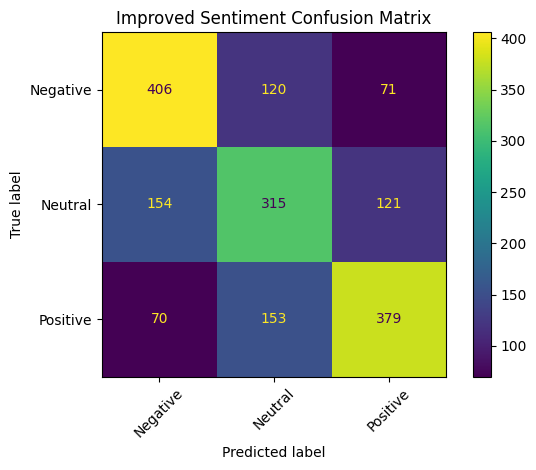

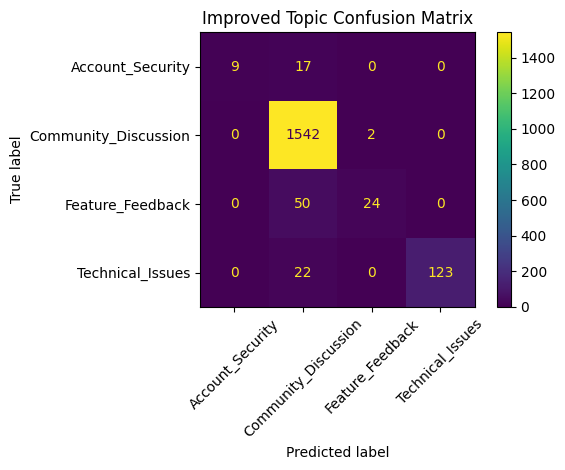

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Sentiment confusion matrix
sentiment_pred = improved_sentiment_model.predict(test_df["post_text"])

ConfusionMatrixDisplay.from_predictions(
    test_df["sentiment_label"],
    sentiment_pred,
    xticks_rotation=45
)
plt.title("Improved Sentiment Confusion Matrix")
plt.tight_layout()
plt.show()


# Topic confusion matrix
topic_pred = improved_topic_model.predict(test_df["post_text"])

ConfusionMatrixDisplay.from_predictions(
    test_df["topic_category"],
    topic_pred,
    xticks_rotation=45
)
plt.title("Improved Topic Confusion Matrix")
plt.tight_layout()
plt.show()

In [74]:
# This experiment performs validation entirely within the training data.
# We are not using the final test_df for hyperparameter tuning.

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Validation split
X_train, X_val, y_train, y_val = train_test_split(
    train_df["post_text"].fillna("").astype(str),
    train_df["sentiment_label"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["sentiment_label"]
)

# Word + character features
features = FeatureUnion([
    ("word", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        sublinear_tf=True
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=50000,
        sublinear_tf=True
    ))
])

# Different regularization values compare karenge
results = []

for c_value in [0.5, 1.0, 2.0, 4.0]:
    model = Pipeline([
        ("features", features),
        ("clf", LogisticRegression(
            C=c_value,
            class_weight="balanced",
            max_iter=2000
        ))
    ])

    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    results.append({
        "C": c_value,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Macro_F1": f1_score(y_val, val_pred, average="macro")
    })

# Results ko macro F1 ke hisaab se dekho
results_df = __import__("pandas").DataFrame(results)
display(results_df.sort_values("Macro_F1", ascending=False))

,C,Accuracy,Macro_F1
1,1.0,0.675676,0.674843
2,2.0,0.675676,0.674830
3,4.0,0.672211,0.671492
0,0.5,0.672211,0.670729


In [90]:
# Function to create the pipeline with configurable regularization C
def make_model(C=1.0):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=100000, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=1500, class_weight="balanced", C=C))
    ])

# Full training data for sentiment model train
final_sentiment_model = make_model(C=1.0)
final_sentiment_model.fit(
    train_df["post_text"].fillna("").astype(str),
    train_df["sentiment_label"]
)

# Full training data for topic model train
final_topic_model = make_model(C=1.0)
final_topic_model.fit(
    train_df["post_text"].fillna("").astype(str),
    train_df["topic_category"]
)

# Output folder mein models save
OUT.mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_sentiment_model,
    OUT / "sentiment_model.pkl"
)

joblib.dump(
    final_topic_model,
    OUT / "topic_model.pkl"
)

print("Models saved successfully!")
print("Sentiment:", OUT / "sentiment_model.pkl")
print("Topic:", OUT / "topic_model.pkl")

Models saved successfully!
Sentiment: outputs/sentiment_model.pkl
Topic: outputs/topic_model.pkl
